Trying different type of models for LST estimation

## General paths, libraries and functions

In [1]:
!pip install seaborn
!pip install statsmodels
!pip install rasterstats


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from rasterstats import zonal_stats
import joblib


In [3]:
# Temperature data
lst_clipped_path = '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LST_clipped_celsius.tif' #values out of city boundary are nan

# variables - Best results (pearson correlation with LST) for window size
ndwi_1_path = '../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/moving-windows/ndwi/Class_1_window61.tif'
ndvi_1_path = '../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/moving-windows/ndvi/Class_1_window25.tif'
ndvi_0p5_path = '../../../datos-notebooks/1.HR-data-bologna/1.1.land-cover/moving-windows/ndvi/Class_0p5_window5.tif' #no se usó
veg_vol_path = '../../../datos-notebooks/1.HR-data-bologna/1.2.objects-height/moving-windows/tree-volume/trees_window13.tif' #no se usó
built_vol_path = '../../../datos-notebooks/1.HR-data-bologna/1.2.objects-height/moving-windows/building-volume/buildings_window13.tif' #no se usó
veg_height_path = '../../../datos-notebooks/1.HR-data-bologna/1.2.objects-height/moving-windows/tree-height/trees_height_window7.tif'
built_area_path = '../../../datos-notebooks/1.HR-data-bologna/1.2.objects-height/moving-windows/building-area/building_area_window11.tif'
building_height_path = '../../../datos-notebooks/1.HR-data-bologna/1.2.objects-height/moving-windows/building-height/building_height_window21.tif'
mean_elev_path = '../../../datos-notebooks/1.HR-data-bologna/1.3.topography/moving_windows/elev_mean/elev_mean_win111.tif'
mean_slope_path = '../../../datos-notebooks/1.HR-data-bologna/1.3.topography/moving_windows/slope_mean/slope_mean_win13.tif'
northness_path = '../../../datos-notebooks/1.HR-data-bologna/1.3.topography/moving_windows/northness/northness_win79.tif'

census_areas_path = '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/vectors/sezioni-di-censimento-anno-2011.geojson'

# output directorys
lst_prediction_folder = '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/' 
os.makedirs(lst_prediction_folder, exist_ok=True)
standarized_folder_path = os.path.join(lst_prediction_folder, 'standarized_variables')


In [4]:
def stepwise_selection_aic(X, y, initial_list=None, min_delta=5, verbose=True):
    """
    Forward-backward stepwise selection based on AIC.
    """
    if initial_list is None:
        included = []
    else:
        included = list(initial_list)

    # Fit initial model (if any)
    if included:
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        current_aic = model.aic
    else:
        current_aic = np.inf

    while True:
        changed = False

        # ---------- Forward step ----------
        excluded = list(set(X.columns) - set(included))
        best_candidate = None
        best_aic = current_aic

        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_candidate = col

        if best_candidate is not None and (current_aic - best_aic) > min_delta:
            included.append(best_candidate)
            current_aic = best_aic
            changed = True
            if verbose:
                print(f"Add {best_candidate:30} AIC = {best_aic:.2f}")

        # ---------- Backward step ----------
        if included:
            worst_candidate = None
            best_aic_back = current_aic

            for col in included:
                temp = included.copy()
                temp.remove(col)
                if temp:
                    model = sm.OLS(y, sm.add_constant(X[temp])).fit()
                    if model.aic < best_aic_back:
                        best_aic_back = model.aic
                        worst_candidate = col

            if worst_candidate is not None and (current_aic - best_aic_back) > min_delta:
                included.remove(worst_candidate)
                current_aic = best_aic_back
                changed = True
                if verbose:
                    print(f"Drop {worst_candidate:30} AIC = {best_aic_back:.2f}")

        if not changed:
            break

    return included


## Dataset preparation

### mask rasters to city boundary

In [5]:
with rasterio.open(lst_clipped_path) as src:
    lst = src.read(1)

lst_mask = np.isnan(lst)

# mask values out of city boundary
ndwi_1 = np.where(lst_mask, np.nan, rasterio.open(ndwi_1_path).read(1).astype("float32"))
ndvi_1 = np.where(lst_mask, np.nan, rasterio.open(ndvi_1_path).read(1).astype("float32"))
ndvi_0p5 = np.where(lst_mask, np.nan, rasterio.open(ndvi_0p5_path).read(1).astype("float32"))
veg_vol = np.where(lst_mask, np.nan, rasterio.open(veg_vol_path).read(1).astype("float32"))
built_vol = np.where(lst_mask, np.nan, rasterio.open(built_vol_path).read(1).astype("float32"))
built_area = np.where(lst_mask, np.nan, rasterio.open(built_area_path).read(1).astype("float32"))
built_height = np.where(lst_mask, np.nan, rasterio.open(building_height_path).read(1).astype("float32"))
mean_elev = np.where(lst_mask, np.nan, rasterio.open(mean_elev_path).read(1).astype("float32"))
mean_slope = np.where(lst_mask, np.nan, rasterio.open(mean_slope_path).read(1).astype("float32"))
northness = np.where(lst_mask, np.nan, rasterio.open(northness_path).read(1).astype("float32"))
veg_height = np.where(lst_mask, np.nan, rasterio.open(veg_height_path).read(1).astype("float32"))

rasters_masked = {
    "Water": ndwi_1,
    "Dense vegetation presence": ndvi_1,
    "Sparse vegetation presence": ndvi_0p5,
    "Vegetation volume": veg_vol,
    "Built volume": built_vol,
    "Built area": built_area,
    "Building height": built_height,
    "Elevation": mean_elev,
    "Slope": mean_slope,
    "Northness": northness,
    "Vegetation height": veg_height
}


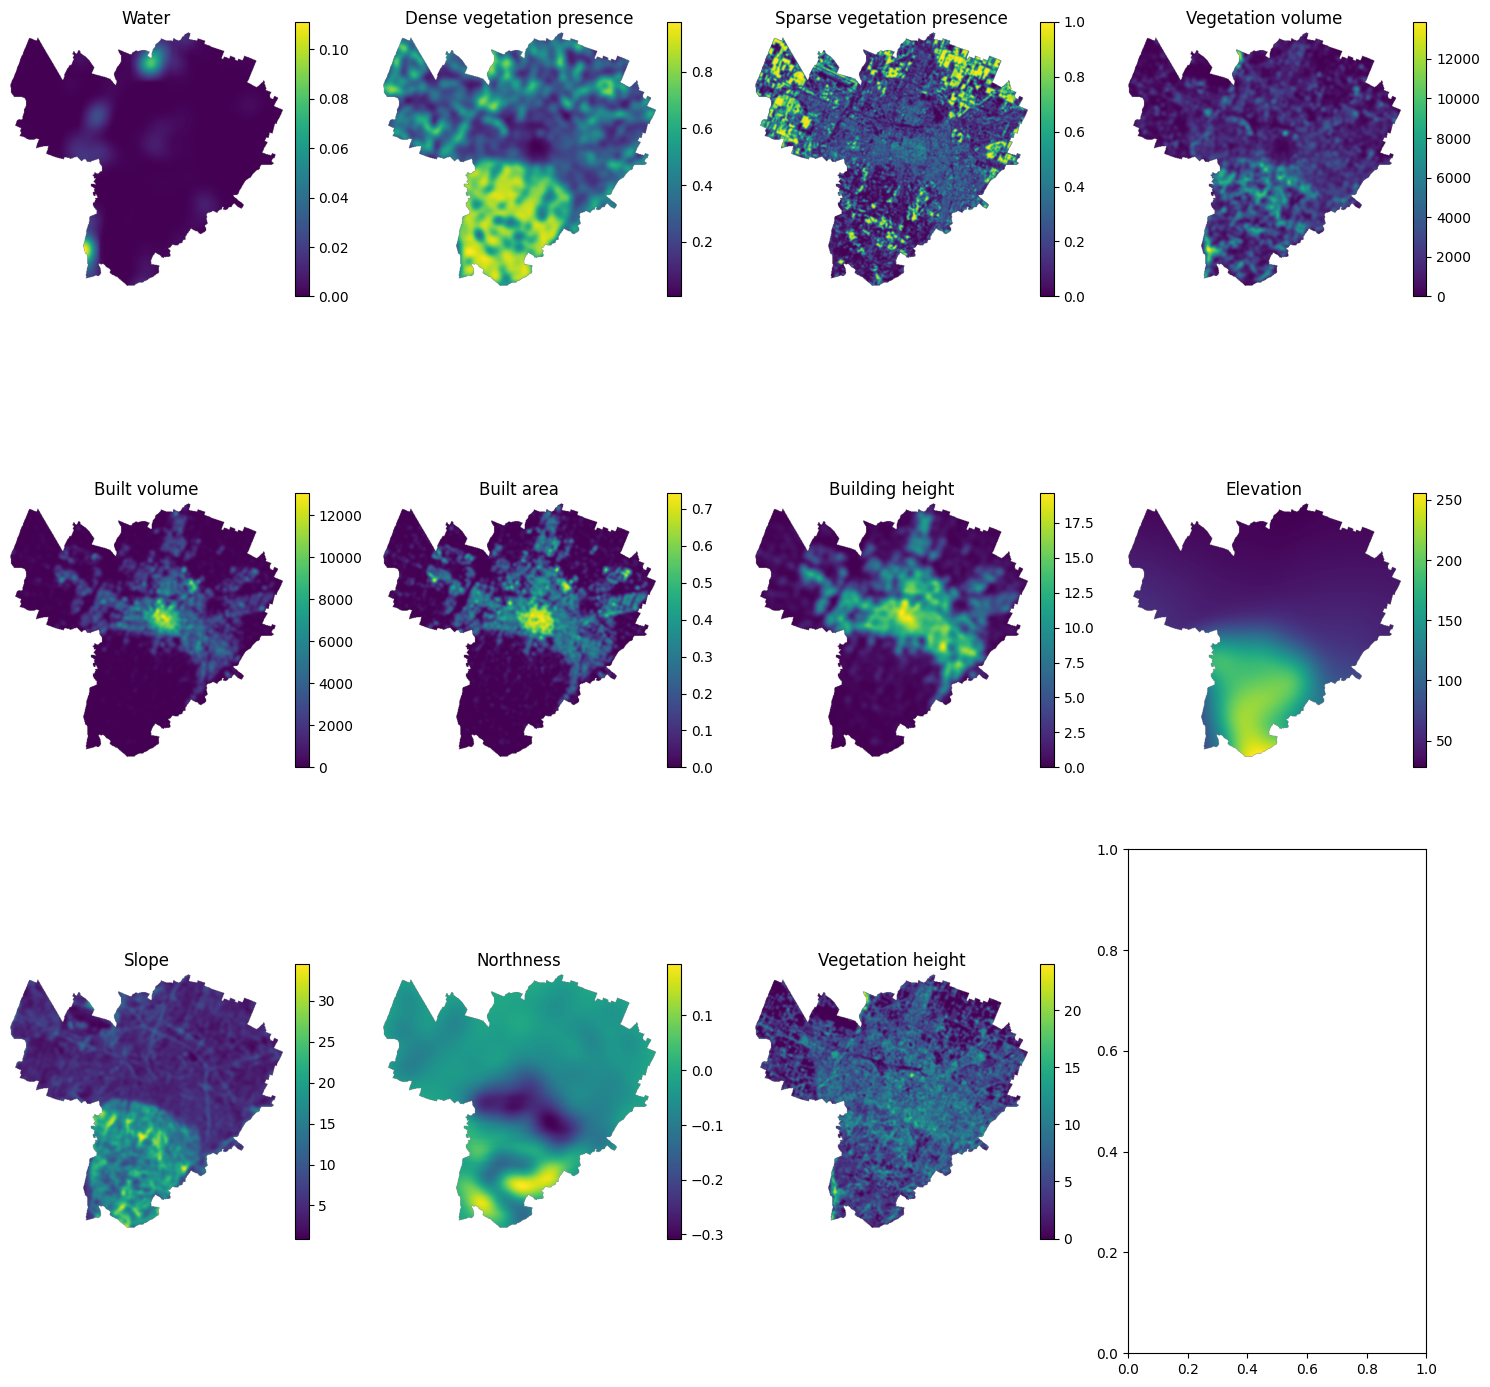

In [6]:
#plot masked rasters 

fig, axes = plt.subplots(3, 4, figsize=(15, 15))

for ax, (name, data) in zip(axes.flat, rasters_masked.items()):

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

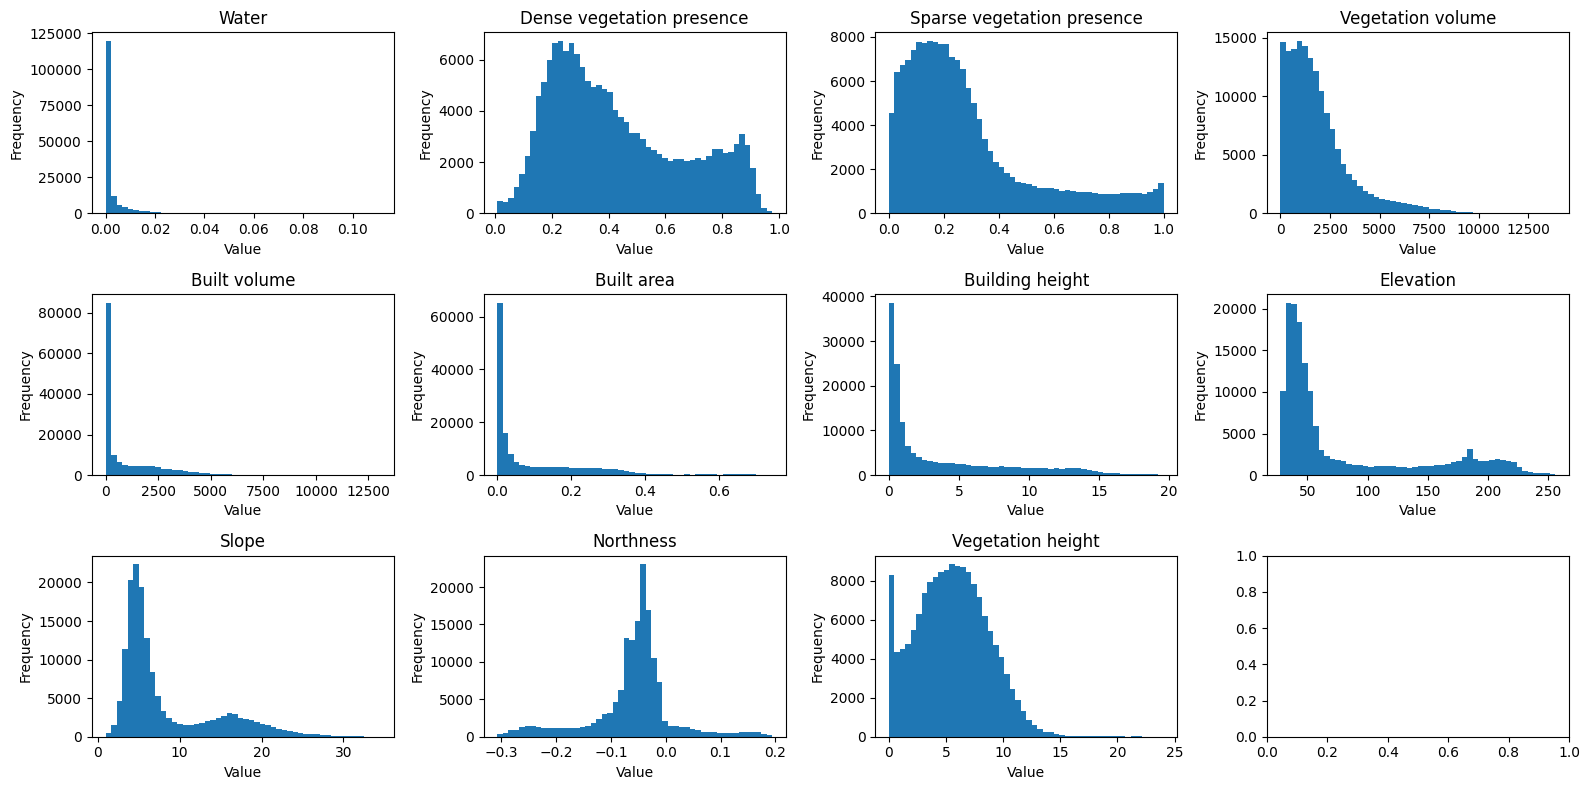

In [7]:
# Plot histograms of masked rasters
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, arr) in enumerate(rasters_masked.items()):
    # Plot histogram using already-masked arrays
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots (if less than 8 rasters)
for j in range(i + 1, 8):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### standarize variables - mean:0, std:1

In [8]:
os.makedirs(standarized_folder_path, exist_ok=True)

In [9]:
# Z-score standardization for regression predictors

def standardize_array(arr, profile, out_path):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    z = (arr - mean) / std

    profile.update(dtype='float32')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(z.astype('float32'), 1)

In [10]:
# Apply standarization
with rasterio.open(lst_clipped_path) as src:
    profile = src.profile.copy()
    
standardize_array(ndwi_1, profile, os.path.join(standarized_folder_path, 'NDWI_1_z.tif'))
standardize_array(ndvi_1, profile, os.path.join(standarized_folder_path, 'NDVI_1_z.tif'))
standardize_array(ndvi_0p5, profile, os.path.join(standarized_folder_path, 'NDVI_0p5_z.tif'))
standardize_array(veg_vol, profile, os.path.join(standarized_folder_path, 'VEG_VOL_z.tif'))
standardize_array(built_vol, profile, os.path.join(standarized_folder_path, 'BUILT_VOL_z.tif'))
standardize_array(built_area, profile, os.path.join(standarized_folder_path, 'BUILT_AREA_z.tif'))
standardize_array(built_height, profile, os.path.join(standarized_folder_path, 'BUILDING_HEIGHT_z.tif'))
standardize_array(mean_elev, profile, os.path.join(standarized_folder_path, 'ELEV_z.tif'))
standardize_array(mean_slope, profile, os.path.join(standarized_folder_path, 'SLOPE_z.tif'))
standardize_array(northness, profile, os.path.join(standarized_folder_path, 'NORTH_z.tif'))
standardize_array(veg_height, profile, os.path.join(standarized_folder_path, 'VEG_HEIGHT_z.tif'))

In [ ]:
std_rasters_paths = {
    "Agua": os.path.join(standarized_folder_path, "NDWI_1_z.tif"),
    "Vegetación densa": os.path.join(standarized_folder_path, "NDVI_1_z.tif"),
    #"Vegetación dispersa": os.path.join(standarized_folder_path, "NDVI_0p5_z.tif"),
    #"Volumen de vegetación": os.path.join(standarized_folder_path, "VEG_VOL_z.tif"),
    #"Volumen construido": os.path.join(standarized_folder_path, "BUILT_VOL_z.tif"),  # Excluido por duplicación de información
    "Área construida": os.path.join(standarized_folder_path, "BUILT_AREA_z.tif"),
    "Altura de edificación": os.path.join(standarized_folder_path, "BUILDING_HEIGHT_z.tif"),
    "Elevación": os.path.join(standarized_folder_path, "ELEV_z.tif"),
    "Pendiente": os.path.join(standarized_folder_path, "SLOPE_z.tif"),
    "Orientación norte": os.path.join(standarized_folder_path, "NORTH_z.tif"),
    "Altura de vegetación": os.path.join(standarized_folder_path, "VEG_HEIGHT_z.tif")    
}

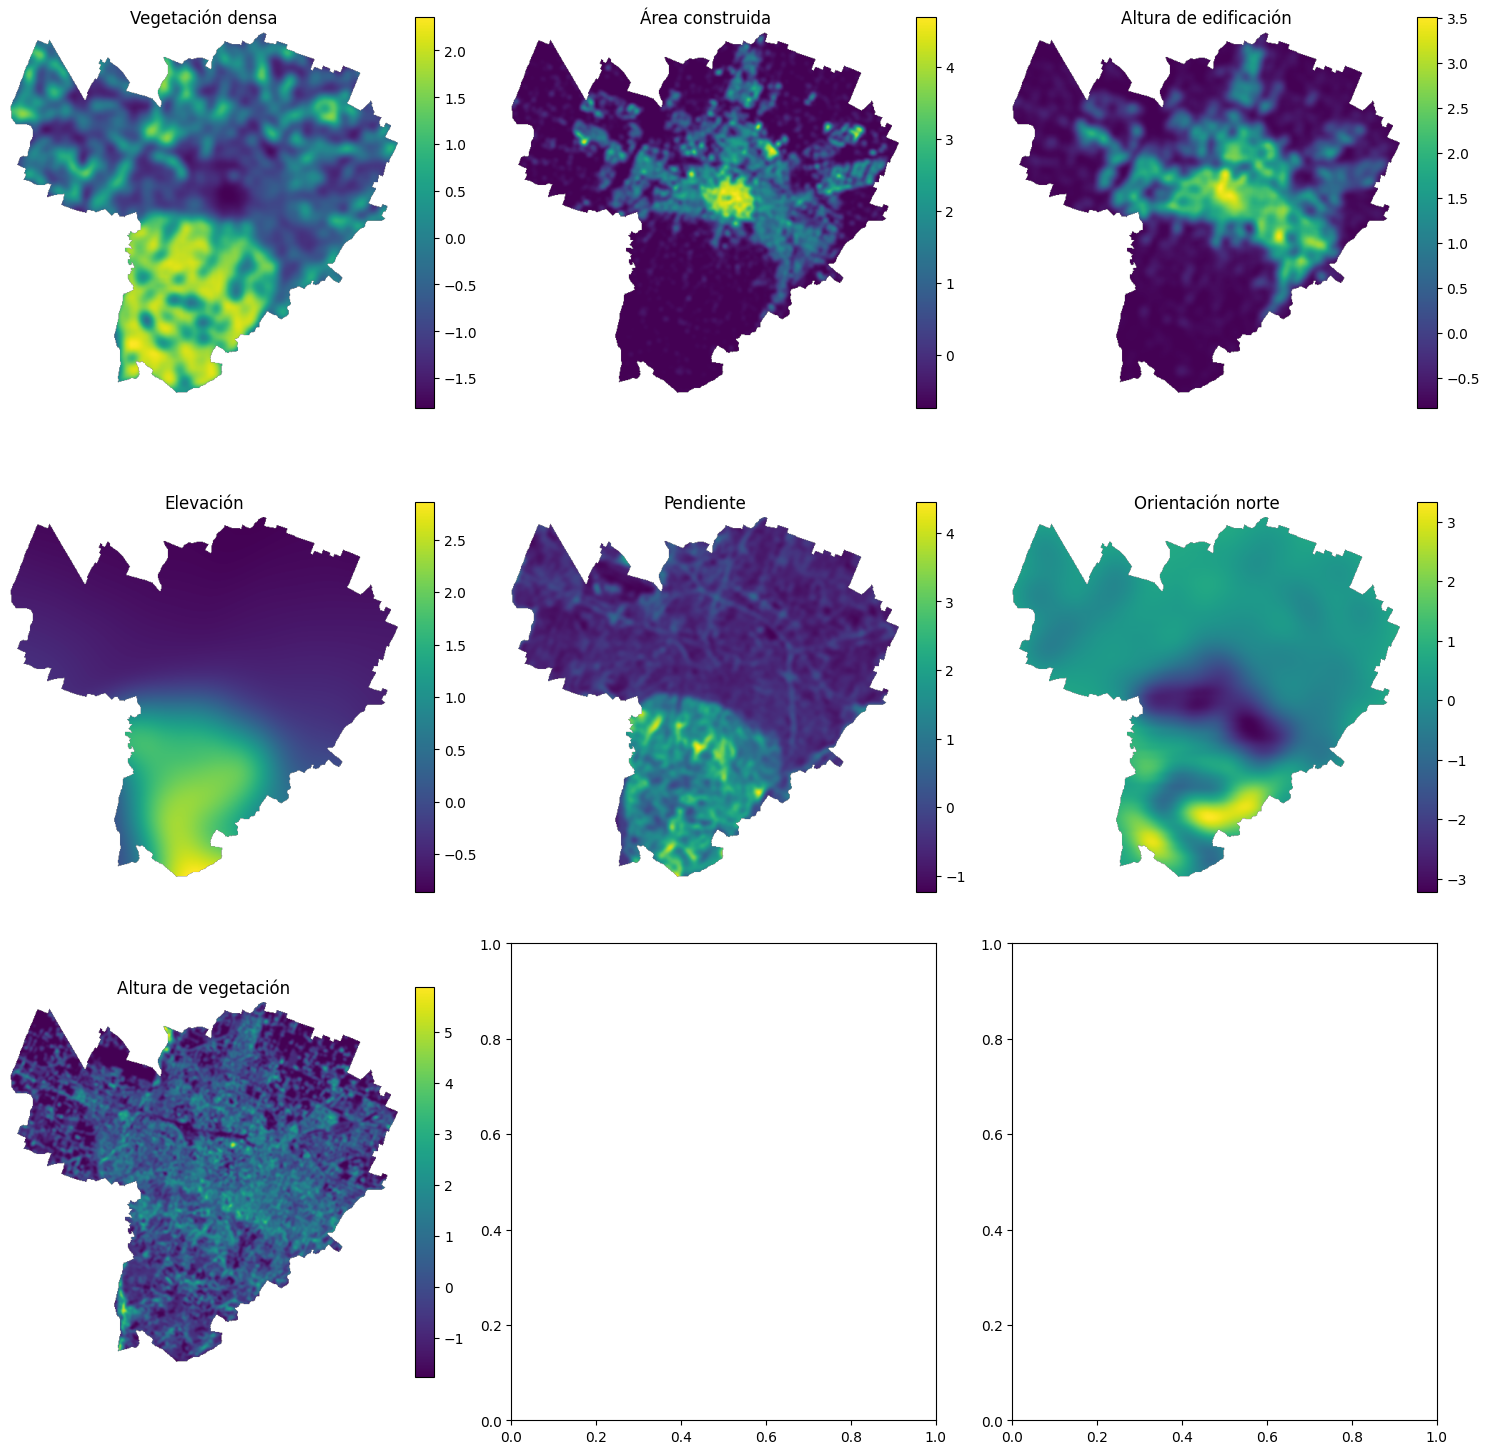

In [12]:
#plot cropped and standardized rasters

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, (name, path) in zip(axes.flat, std_rasters_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

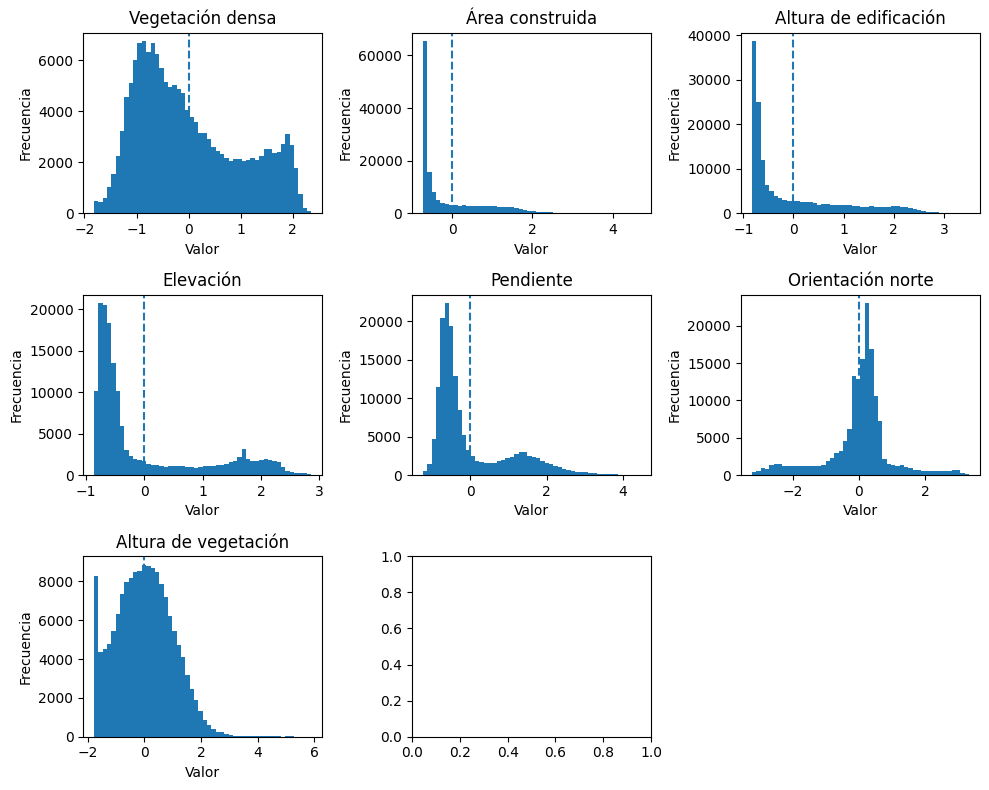

In [13]:
# plot histograms of standardized rasters

fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, path) in enumerate(std_rasters_paths.items()):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

    # Plot histogram
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")
    axes[i].axvline(0, linestyle='--')
    
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### stratified sampling of LST

In [14]:
rasters = {"LST": lst_clipped_path} # create dictionary with LST raster 
rasters.update(std_rasters_paths) # add standardized rasters to the dictionary
#rasters.pop("Variable name", None) # to delete one variable if needed

In [15]:
rasters

{'LST': '../../../datos-notebooks/1.HR-data-bologna/1.0.base-data/LST/LST_clipped_celsius.tif',
 'Vegetación densa': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\NDVI_1_z.tif',
 'Área construida': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\BUILT_AREA_z.tif',
 'Altura de edificación': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\BUILDING_HEIGHT_z.tif',
 'Elevación': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\ELEV_z.tif',
 'Pendiente': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\SLOPE_z.tif',
 'Orientación norte': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\NORTH_z.tif',
 'Altura de vegetación': '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/standarized_variables\\VEG_HEIGHT_z.tif'}

In [16]:
# Create bins
n_bins = 10

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

df = df.dropna() # Drop rows with NaN

df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False) # Create LST bins for stratification 

In [17]:
# Stratified sampling: 10% of each bin

sample_fraction = 0.1
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())


         LST  Vegetación densa  Área construida  Altura de edificación  \
0  33.068665          1.827801        -0.639813              -0.602623   
1  32.350883          0.933061        -0.726476              -0.813148   
2  34.319660          1.545045        -0.608553              -0.425379   
3  32.039841          1.338969        -0.706931              -0.778302   
4  34.459801          1.834672        -0.713203              -0.695057   

   Elevación  Pendiente  Orientación norte  Altura de vegetación  
0   1.028075   1.783342          -1.693125              0.220664  
1  -0.813894   0.295745           0.679544              3.150552  
2   0.767098   1.388541          -2.369040             -0.292155  
3   1.145647   2.951268          -1.143624              1.850412  
4   2.276554   2.143288           0.471531              0.172077  


C:\Users\guada\AppData\Local\Temp\ipykernel_11088\4163941717.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('LST_bin', group_keys=False).apply(


In [18]:
# Show min, max and count of LST values in each bin

df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False) # Recreate bins for the sampled dataset

for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")

df_sampled = df_sampled.drop(columns=['LST_bin'])

Bin 0: min = 30.58, max = 34.56, count = 1565
Bin 1: min = 34.57, max = 36.29, count = 1565
Bin 2: min = 36.29, max = 37.56, count = 1566
Bin 3: min = 37.57, max = 38.56, count = 1565
Bin 4: min = 38.57, max = 39.43, count = 1564
Bin 5: min = 39.44, max = 40.22, count = 1570
Bin 6: min = 40.22, max = 40.95, count = 1560
Bin 7: min = 40.96, max = 41.74, count = 1566
Bin 8: min = 41.74, max = 42.86, count = 1562
Bin 9: min = 42.86, max = 51.39, count = 1564


### Descriptive statistics

In [19]:
# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

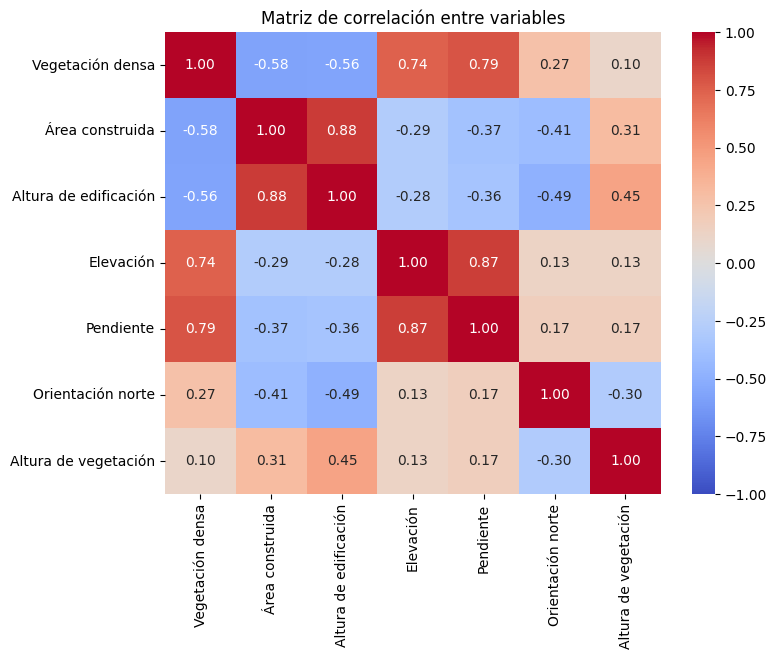

In [20]:
# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables")
plt.show()


In [21]:
# Vegetation plot: area vs volume
plt.figure()
plt.scatter(
    df_sampled["Dense veg. presence"],
    df_sampled["Vegetation height"],
    s=1, alpha=0.5
)
plt.xlabel("Vegetation presence (z)")
plt.ylabel("Vegetation height (z)")
plt.title("Vegetation: Area vs Height")
plt.show()

# Built plot: area vs height
plt.figure()
plt.scatter(
    df_sampled["Built Area"],
    df_sampled["Built Height"],
    s=1, alpha=0.5
)
plt.xlabel("Built area (z)")
plt.ylabel("Built Height (z)")
plt.title("Built: Area vs Height")
plt.show()


KeyError: 'Dense veg. presence'

<Figure size 640x480 with 0 Axes>

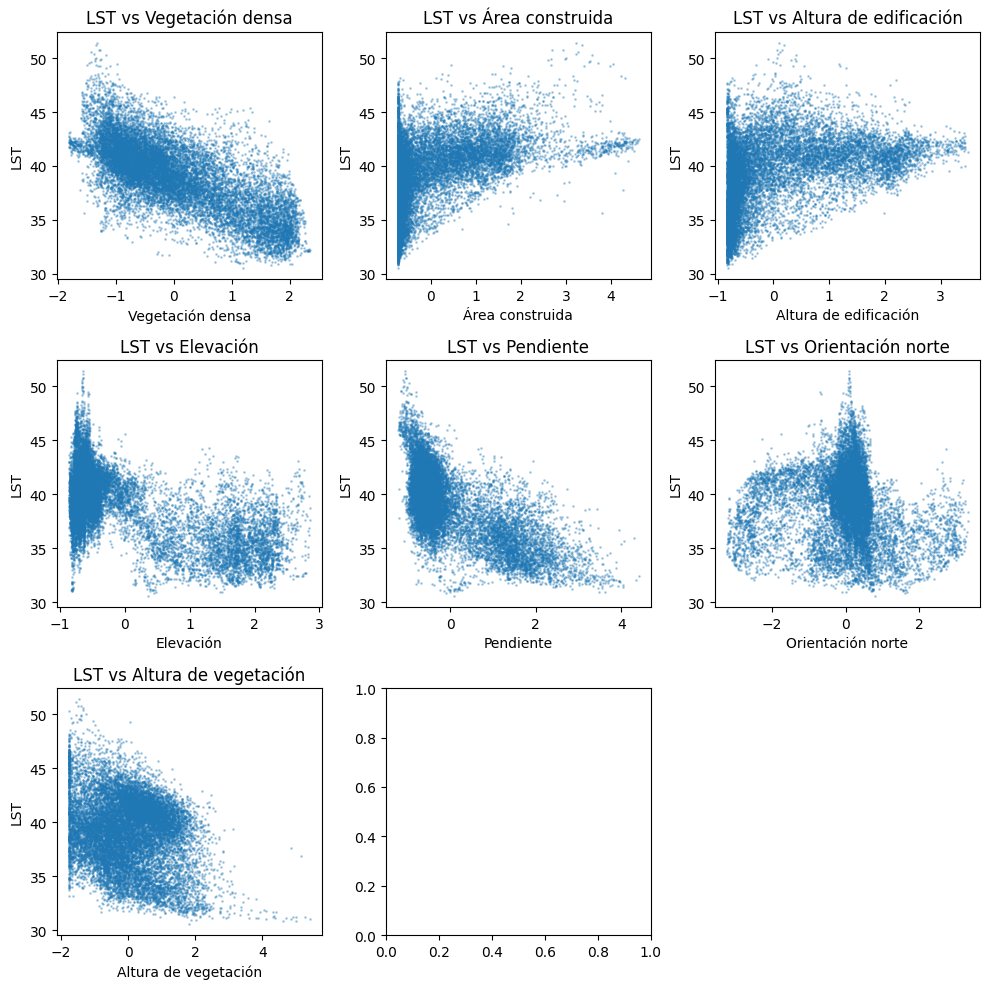

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten() 

for i, v in enumerate(X.columns):
    axes[i].scatter(X[v], y, s=1, alpha=0.3)
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("LST")
    axes[i].set_title(f"LST vs {v}")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

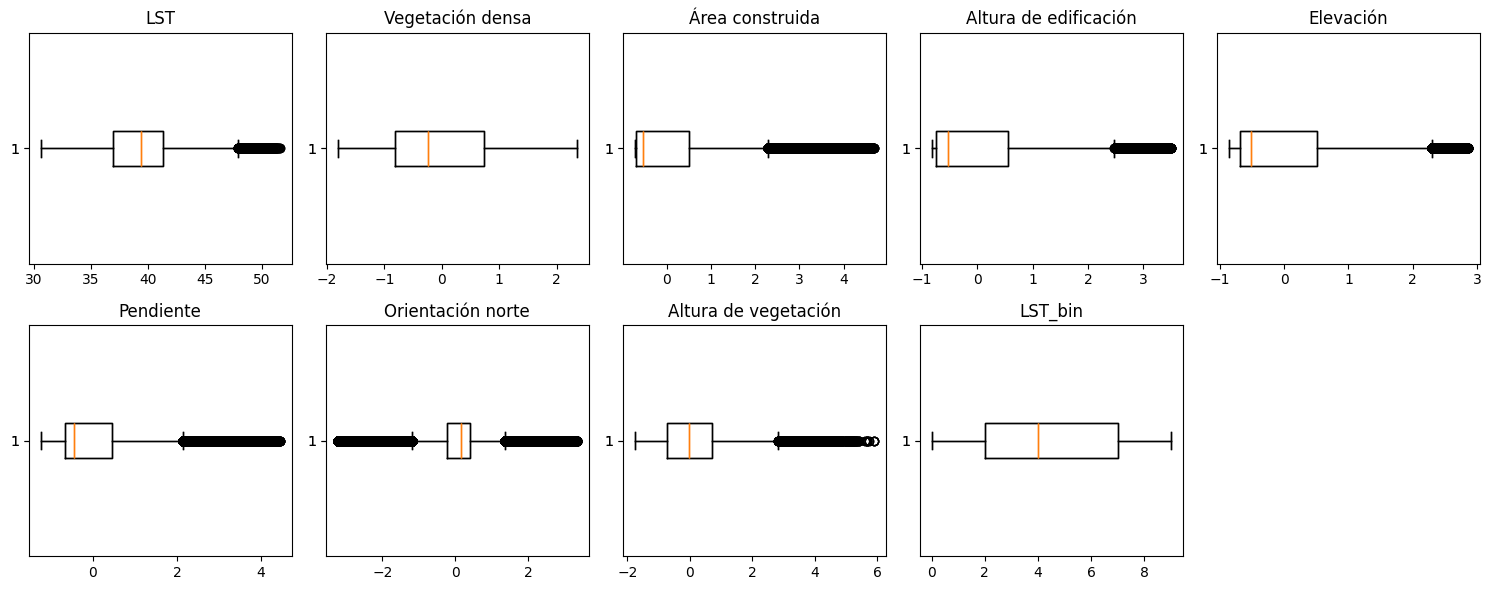

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, v in enumerate(df.columns[:10]):
    axes[i].boxplot(df[v], vert=False)
    axes[i].boxplot(df[v], vert=False)
    axes[i].set_title(v)

for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### PCA

In [24]:
df_sampled

,LST,Vegetación densa,Área construida,Altura de edificación,Elevación,Pendiente,Orientación norte,Altura de vegetación
0,33.068665,1.827801,-0.639813,-0.602623,1.028075,1.783342,-1.693125,0.220664
1,32.350883,0.933061,-0.726476,-0.813148,-0.813894,0.295745,0.679544,3.150552
2,34.319660,1.545045,-0.608553,-0.425379,0.767098,1.388541,-2.369040,-0.292155
3,32.039841,1.338969,-0.706931,-0.778302,1.145647,2.951268,-1.143624,1.850412
4,34.459801,1.834672,-0.713203,-0.695057,2.276554,2.143288,0.471531,0.172077
...,...,...,...,...,...,...,...,...
15642,47.526890,-1.050920,2.383266,1.294325,-0.662805,-0.671113,0.169985,-0.265153
15643,45.455570,-0.818889,2.005772,0.798833,-0.548723,-0.811179,0.375657,-1.147865
15644,43.203094,-0.869769,0.350855,1.212772,-0.540285,-0.414426,-0.345219,-0.893892
15645,43.404758,-1.099255,1.265501,1.672183,-0.590957,-0.362915,0.185519,0.474263


In [25]:
y = df_sampled["LST"].values
X = df_sampled.drop(columns=["LST"])

In [26]:
X

,Vegetación densa,Área construida,Altura de edificación,Elevación,Pendiente,Orientación norte,Altura de vegetación
0,1.827801,-0.639813,-0.602623,1.028075,1.783342,-1.693125,0.220664
1,0.933061,-0.726476,-0.813148,-0.813894,0.295745,0.679544,3.150552
2,1.545045,-0.608553,-0.425379,0.767098,1.388541,-2.369040,-0.292155
3,1.338969,-0.706931,-0.778302,1.145647,2.951268,-1.143624,1.850412
4,1.834672,-0.713203,-0.695057,2.276554,2.143288,0.471531,0.172077
...,...,...,...,...,...,...,...
15642,-1.050920,2.383266,1.294325,-0.662805,-0.671113,0.169985,-0.265153
15643,-0.818889,2.005772,0.798833,-0.548723,-0.811179,0.375657,-1.147865
15644,-0.869769,0.350855,1.212772,-0.540285,-0.414426,-0.345219,-0.893892
15645,-1.099255,1.265501,1.672183,-0.590957,-0.362915,0.185519,0.474263


In [27]:
predictor_names = X.columns.tolist()

# Standardization
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)


In [28]:
# Save objects for modelling with global data then
joblib.dump(scaler, os.path.join(lst_prediction_folder, "scaler_pca.pkl"))
joblib.dump(pca, os.path.join(lst_prediction_folder, "pca.pkl"))
joblib.dump(predictor_names, os.path.join(lst_prediction_folder, "predictor_names_pca.pkl"))

# for using in another notebook:
'''
import joblib

# Load objects
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")
predictor_names = joblib.load("predictor_names.pkl")

# Apply to new data
X_std = scaler.transform(X)
X_pca = pca.transform(X_std)

'''

'\nimport joblib\n\n# Load objects\nscaler = joblib.load("scaler.pkl")\npca = joblib.load("pca.pkl")\npredictor_names = joblib.load("predictor_names.pkl")\n\n# Apply to new data\nX_std = scaler.transform(X)\nX_pca = pca.transform(X_std)\n\n'

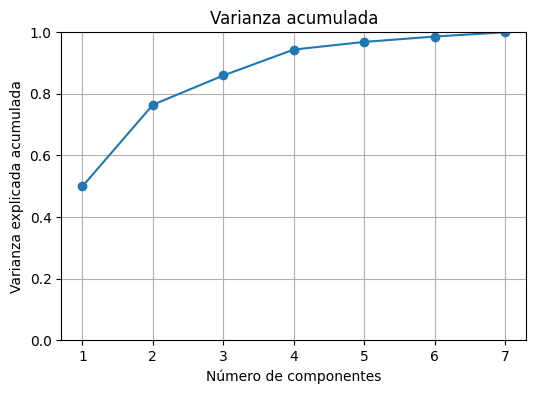

In [29]:
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.ylim(0,1)
plt.title("Varianza acumulada")
plt.grid(True)
plt.show()

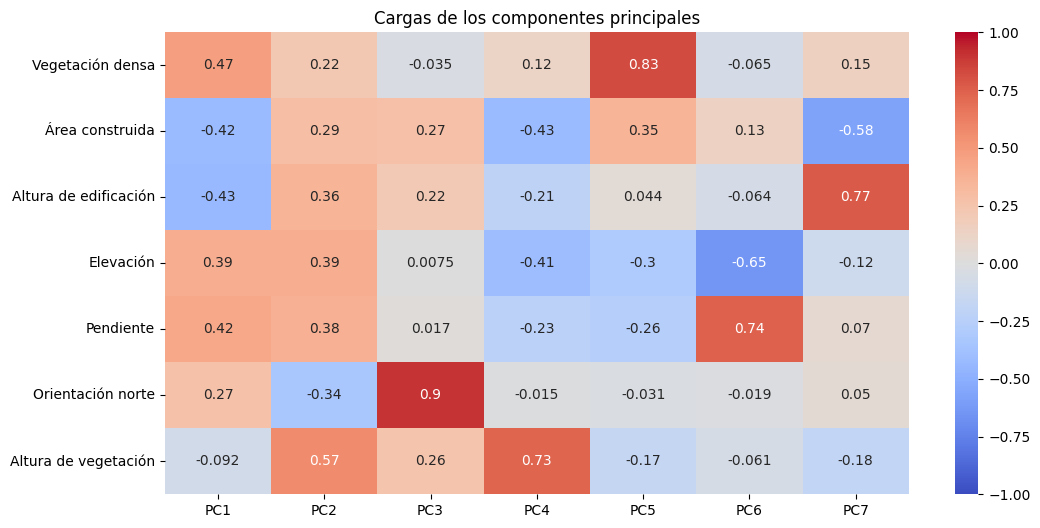

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(X.shape[1])],
    index=predictor_names
)

plt.figure(figsize=(12,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Cargas de los componentes principales")
plt.show()


## Different models

### linear regression using PCs

In [31]:
X = X_pca[:, :8]  # Choose how many PCs to use
y = df_sampled["LST"].values


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Add intercept for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)


ols_model = sm.OLS(y_train, X_train_sm).fit() # Fit OLS model

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     2967.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:26:36   Log-Likelihood:                -22426.
No. Observations:               10952   AIC:                         4.487e+04
Df Residuals:                   10944   BIC:                         4.493e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.1363      0.018   2183.197      0.0

In [32]:
# save for using in another notebook
joblib.dump(ols_model, os.path.join(lst_prediction_folder, "ols_model_pcs.pkl"))


['../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/ols_model_pcs.pkl']

In [33]:
# Error metrics on test set
y_pred = ols_model.predict(X_test_sm) # Predict on test set

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.648
Test set RMSE: 1.869


### linear regression using PCs + stepwise

In [34]:
X = X_pca[:, :8]  # Choose how many PCs to use
y = df_sampled["LST"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Convert PCs to DataFrame with numbers as column names
X_df = pd.DataFrame(X_train, columns=[f"PC{i+1}" for i in range(X_train.shape[1])])
y_train_vals = y_train  # already an array

# Stepwise selection using function
selected_pcs = stepwise_selection_aic(
    X=X_df,
    y=y_train_vals,
    initial_list=None,   
    min_delta=500,       # change if needed
    verbose=True        
)

print("\nSelected PCs (train):", selected_pcs)



Add PC1                            AIC = 49701.17
Add PC2                            AIC = 46721.94
Add PC4                            AIC = 45262.91

Selected PCs (train): ['PC1', 'PC2', 'PC4']


In [35]:
pc_names = [f"PC{i+1}" for i in range(X_train.shape[1])]

# Fit final model on train with selected PCs
final_idx = [pc_names.index(v) for v in selected_pcs]
X_train_final = X_train_sm[:, [0] + [i+1 for i in final_idx]]
X_test_final  = X_test_sm[:, [0] + [i+1 for i in final_idx]]

final_model = sm.OLS(y_train, X_train_final).fit()
print("\n--- Train summary ---")
print(final_model.summary())


--- Train summary ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     6543.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:26:36   Log-Likelihood:                -22627.
No. Observations:               10952   AIC:                         4.526e+04
Df Residuals:                   10948   BIC:                         4.529e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.1372      0.

In [36]:
# save for using in another notebook
joblib.dump(
    final_model,
    os.path.join(lst_prediction_folder, "ols_model_pcs_stepwise.pkl")
)

joblib.dump(
    selected_pcs,
    os.path.join(lst_prediction_folder, "selected_pcs_stepwise.pkl")
)


['../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/selected_pcs_stepwise.pkl']

In [37]:
# Error metrics with test set

y_pred = final_model.predict(X_test_final) # Predict on test set


r2_test = r2_score(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2_test:.3f}")
print(f"Test set RMSE: {rmse_test:.3f}")



Test set R²: 0.631
Test set RMSE: 1.913


### linear regression using original variables

In [38]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add intercept (constant) for OLS
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit() # Fit OLS model on training set

print(ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:                    LST   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     3414.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:26:36   Log-Likelihood:                -25594.
No. Observations:               12517   AIC:                         5.120e+04
Df Residuals:                   12509   BIC:                         5.126e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    39.13

In [40]:
# save for using in another notebook
joblib.dump(
    ols_model,
    os.path.join(lst_prediction_folder, "ols_model_variables.pkl")
)

['../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/ols_model_variables.pkl']

In [41]:
# Error metrics
y_pred = ols_model.predict(X_test_sm) # Predict on test set

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")



Test set R²: 0.638
Test set RMSE: 1.885


### Linear regression using original variables + Stepwise

In [42]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Stepwise selection 
selected_features = stepwise_selection_aic(
    X=X,
    y=y,
    initial_list=None,   
    min_delta=500,       
    verbose=True         
)



Add Vegetación densa               AIC = 68664.02
Add Altura de vegetación           AIC = 67500.37
Add Área construida                AIC = 65823.81
Add Pendiente                      AIC = 64393.20


In [43]:
X = df_sampled[selected_features]
y = df_sampled["LST"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Add intercept (constant) for OLS
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     5022.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:26:36   Log-Likelihood:                -22545.
No. Observations:               10952   AIC:                         4.510e+04
Df Residuals:                   10947   BIC:                         4.514e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   39.1388 

In [44]:
# save for using in another notebook

joblib.dump(
    selected_features,
    os.path.join(lst_prediction_folder, "selected_variables_stepwise.pkl")
)

joblib.dump(
    ols_model,
    os.path.join(lst_prediction_folder, "ols_model_variables_stepwise.pkl")
)


['../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/ols_model_variables_stepwise.pkl']

In [45]:
# Error metrics
y_pred = ols_model.predict(X_test_const)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.639
Test set RMSE: 1.890


### Linear regression using polynomial (grade 2) terms in original variables + stepwise

In [46]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']


In [47]:
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X)

# obtain feature names
poly_features = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly_df, y, test_size=0.3, random_state=42
)


In [48]:
# Stepwise selection on polynomial features (train)
selected_poly_features = stepwise_selection_aic(
    X=X_train,
    y=y_train,
    initial_list=None,  
    min_delta=500,      
    verbose=True        
)

Add Vegetación densa               AIC = 48022.45
Add Altura de vegetación           AIC = 47124.72
Add Área construida                AIC = 46059.31
Add Área construida Altura de edificación AIC = 44516.42
Add Pendiente                      AIC = 43746.54


In [49]:
# Ajust OLS with selected variables
X_train_sel = sm.add_constant(X_train[selected_poly_features])
X_test_sel = sm.add_constant(X_test[selected_poly_features])

ols_poly_model = sm.OLS(y_train, X_train_sel).fit()
print(ols_poly_model.summary())



                            OLS Regression Results                            
Dep. Variable:                    LST   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     4836.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:26:36   Log-Likelihood:                -21867.
No. Observations:               10952   AIC:                         4.375e+04
Df Residuals:                   10946   BIC:                         4.379e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [50]:
# save for using in another notebook
joblib.dump(
    poly,
    os.path.join(lst_prediction_folder, "poly.pkl")
)

joblib.dump(
    selected_poly_features,
    os.path.join(lst_prediction_folder, "poly_stepwise.pkl")
)

joblib.dump(
    ols_poly_model,
    os.path.join(lst_prediction_folder, "ols_model_poly_stepwise.pkl")
)

['../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/ols_model_poly_stepwise.pkl']

In [51]:
# Error metrics
y_pred = ols_poly_model.predict(X_test_sel)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Test set R²: 0.691
Test set RMSE: 1.751


### Random Forest

In [52]:
df_sampled

,LST,Vegetación densa,Área construida,Altura de edificación,Elevación,Pendiente,Orientación norte,Altura de vegetación
0,33.068665,1.827801,-0.639813,-0.602623,1.028075,1.783342,-1.693125,0.220664
1,32.350883,0.933061,-0.726476,-0.813148,-0.813894,0.295745,0.679544,3.150552
2,34.319660,1.545045,-0.608553,-0.425379,0.767098,1.388541,-2.369040,-0.292155
3,32.039841,1.338969,-0.706931,-0.778302,1.145647,2.951268,-1.143624,1.850412
4,34.459801,1.834672,-0.713203,-0.695057,2.276554,2.143288,0.471531,0.172077
...,...,...,...,...,...,...,...,...
15642,47.526890,-1.050920,2.383266,1.294325,-0.662805,-0.671113,0.169985,-0.265153
15643,45.455570,-0.818889,2.005772,0.798833,-0.548723,-0.811179,0.375657,-1.147865
15644,43.203094,-0.869769,0.350855,1.212772,-0.540285,-0.414426,-0.345219,-0.893892
15645,43.404758,-1.099255,1.265501,1.672183,-0.590957,-0.362915,0.185519,0.474263


In [53]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,         # no max depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
# Error metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")




R²: 0.874
RMSE: 1.119


In [55]:
# Variable importance
importances = rf_model.feature_importances_

# Create dataframe for sorting
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="importance", ascending=False)

print("\nVariable importance (Random Forest):")
# Print ordered results
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.3f}")


Variable importance (Random Forest):
Elevación: 0.297
Pendiente: 0.234
Altura de vegetación: 0.137
Vegetación densa: 0.123
Área construida: 0.117
Orientación norte: 0.046
Altura de edificación: 0.046


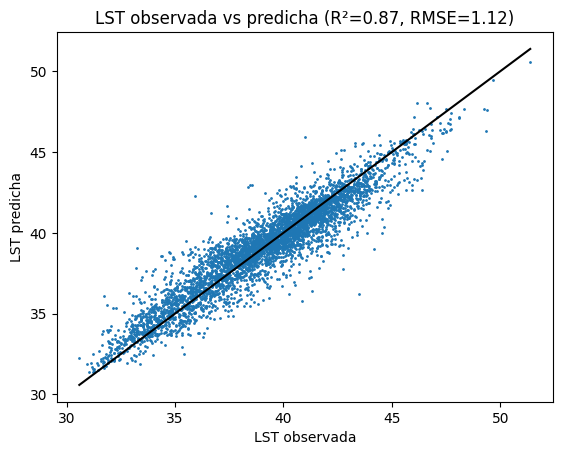

In [56]:
plt.figure()
plt.scatter(y_test, y_pred, s=1)  
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="black")
plt.xlabel("LST observada")
plt.ylabel("LST predicha")
plt.title(f"LST observada vs predicha (R²={r2:.2f}, RMSE={rmse:.2f})")
plt.show()


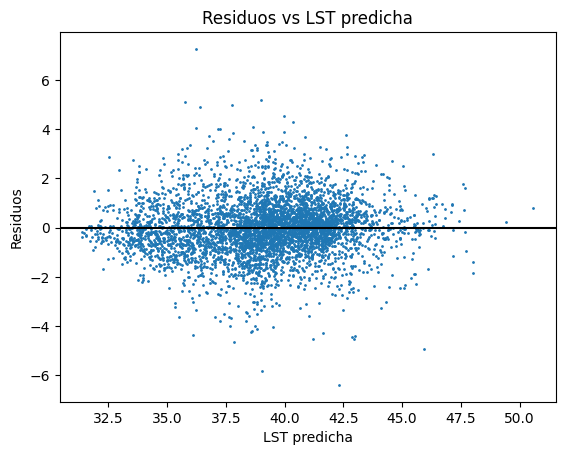

In [57]:
# Residuals plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, s=1)
plt.axhline(0, color='black')
plt.xlabel("LST predicha")
plt.ylabel("Residuos")
plt.title("Residuos vs LST predicha")
plt.show()


In [58]:
# Save trained model
joblib.dump(rf_model, os.path.join(lst_prediction_folder, "rf_model_bologna.pkl"))

['../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/rf_model_bologna.pkl']

## Applying RF model in all the city

In [59]:
print(X.columns.tolist())


['Vegetación densa', 'Área construida', 'Altura de edificación', 'Elevación', 'Pendiente', 'Orientación norte', 'Altura de vegetación']


In [60]:
# Predictor order (MUST match training)
predictor_order = ['Agua', 'Vegetación densa', 'Área construida', 'Altura de edificación', 'Elevación', 'Pendiente', 'Orientación norte', 'Altura de vegetación']


# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

KeyError: 'Agua'

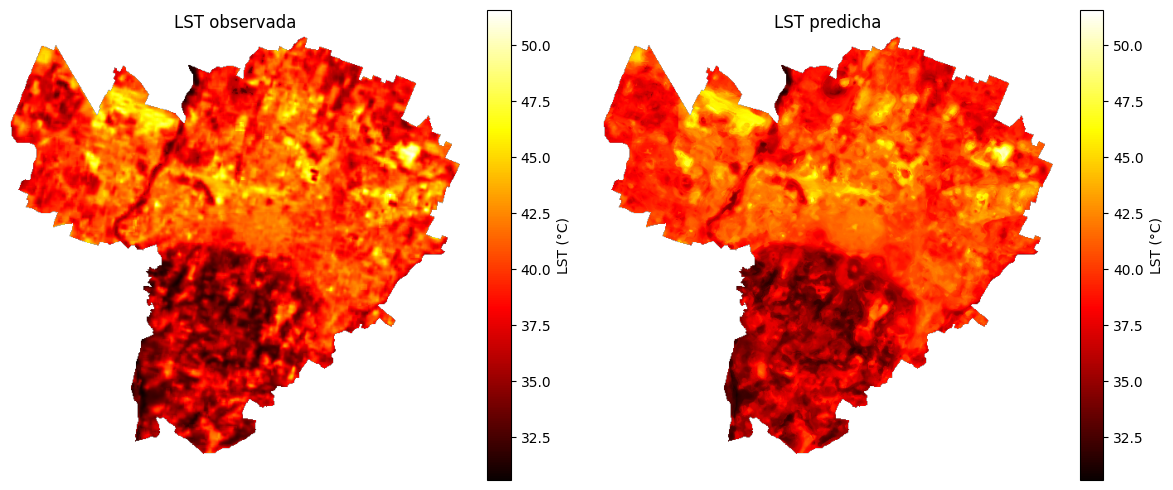

In [ ]:
# Plot observed vs predicted LST

lst_predicted_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(lst_clipped_path) as src:
    lst_observed = src.read(1)

with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    
vmin = np.nanmin(lst_observed)
vmax = np.nanmax(lst_observed)

# Plot 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lst_observed, vmin=vmin, vmax=vmax, cmap="hot")  # thermal colormap
plt.colorbar(label="LST (°C)")
plt.title("LST observada")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lst_pred, vmin=vmin, vmax=vmax, cmap="hot")  # same colormap
plt.colorbar(label="LST (°C)")
plt.title("LST predicha")
plt.axis("off")

plt.tight_layout()
plt.show()


## Extracting results for census areas

In [ ]:
with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    lst_transform = src.transform
    lst_crs = src.crs
    
census_areas = gpd.read_file(census_areas_path)
census_areas = census_areas.to_crs(lst_crs)

In [ ]:
# Extract statistics
stats = zonal_stats(
    census_areas,
    lst_predicted_path,
    stats=["min", "max", "mean"],
    nodata=None  # o poné el nodata real si tu raster lo tiene
)

# Create a new  nuevo GeoDataFrame with statistics + geometry
census_stats = gpd.GeoDataFrame({
    "min_LST":  [s["min"]  for s in stats],
    "max_LST":  [s["max"]  for s in stats],
    "mean_LST": [s["mean"] for s in stats]
},
geometry=census_areas.geometry,
crs=census_areas.crs)


In [ ]:
census_stats.head()

,min_LST,max_LST,mean_LST,geometry
0,41.636780,42.293320,42.089840,"MULTIPOLYGON (((682979.045 4930444.93, 682928...."
1,39.122894,42.316460,40.939673,"MULTIPOLYGON (((682163.461 4930480.473, 682248..."
2,39.759808,42.511768,40.842584,"MULTIPOLYGON (((680647.21 4930374.717, 680641...."
3,40.531818,42.122490,41.052147,"MULTIPOLYGON (((683901.956 4930473.832, 683997..."
4,41.874218,42.554298,42.132770,"MULTIPOLYGON (((685579.299 4930425.746, 685591..."


In [ ]:
census_stats.to_file(os.path.join(lst_prediction_folder,"LST_census_areas.gpkg"), driver="GPKG")

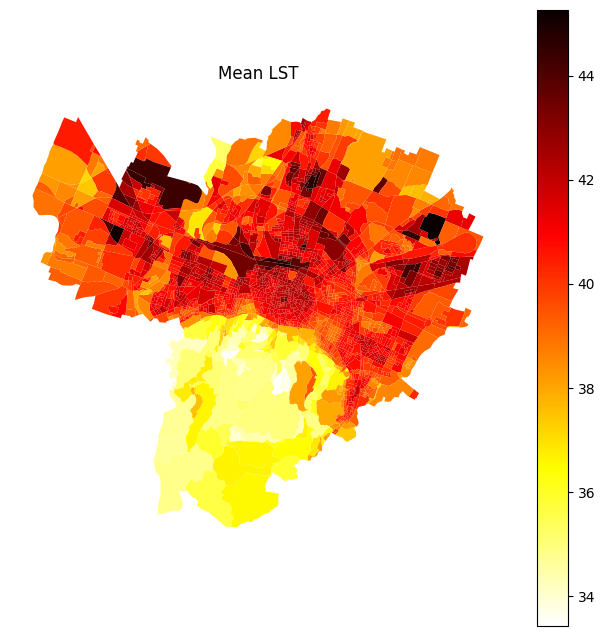

In [ ]:
gdf = gpd.read_file(os.path.join(lst_prediction_folder, "LST_census_areas.gpkg"))

fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(column="mean_LST", cmap="hot_r", legend=True, ax=ax, linewidth=0, edgecolor="none")
ax.set_title("Mean LST")
ax.set_axis_off()
plt.show()


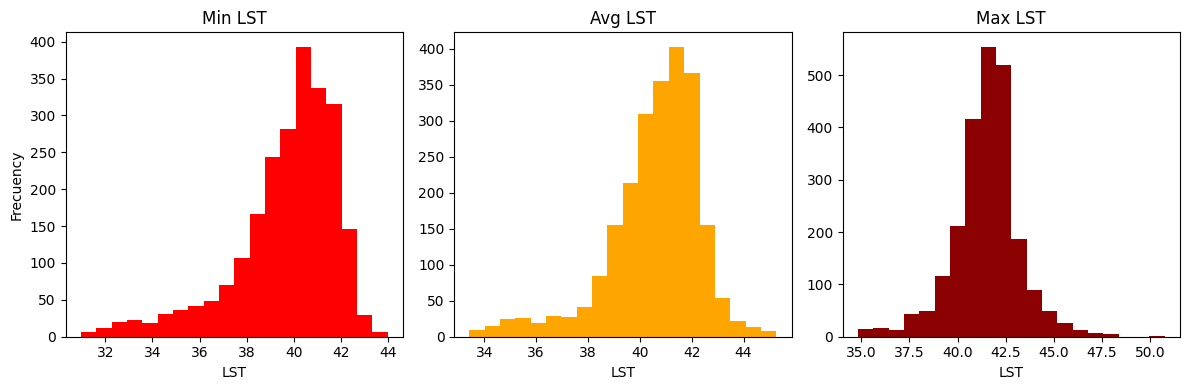

In [ ]:
plt.figure(figsize=(12,4))

# Min
plt.subplot(1,3,1)
plt.hist(census_stats["min_LST"].dropna(), bins=20, color="red")
plt.title("Min LST")
plt.xlabel("LST")
plt.ylabel("Frecuency")

# Mean
plt.subplot(1,3,2)
plt.hist(census_stats["mean_LST"].dropna(), bins=20, color="orange")
plt.title("Avg LST")
plt.xlabel("LST")

# Max
plt.subplot(1,3,3)
plt.hist(census_stats["max_LST"].dropna(), bins=20, color="darkred")
plt.title("Max LST")
plt.xlabel("LST")

plt.tight_layout()
plt.show()
